# 1. Import necessary libraries

In [20]:
import os
import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D, Reshape
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import warnings
warnings.filterwarnings("ignore", message=".*libpng.*")

# 2: Load and Process JSON Labels

In [12]:
# File paths
json_file_path = "photos.json"
image_folder = "./photos"

# Storage
data = []
labels_set = set()  # To store unique labels
missing_images = 0
total_json_entries = 0

# Open and process JSON file
with open(json_file_path, "r") as file:
    for line in file:
        total_json_entries += 1
        try:
            entry = json.loads(line)  # Load JSON safely
            image_path = os.path.join(image_folder, entry["photo_id"] + ".jpg")

            if os.path.exists(image_path):
                data.append((image_path, entry["label"]))  # Store as (image_path, label)
                labels_set.add(entry["label"])
        except json.JSONDecodeError:
            print(f"Skipping corrupted JSON entry at line {total_json_entries}")

# Take a random sample of 1,000 images if the dataset is larger
if len(data) > 1000:
    from random import sample
    data = sample(data, 1000)

# Extract paths and labels separately
image_paths, labels = zip(*data)

# Output summary
print(f"Total JSON entries processed: {total_json_entries}")
print(f"Total images loaded: {len(image_paths)}")
print(f"Total missing images: {missing_images}")
print(f"Unique labels: {labels_set}")

Total JSON entries processed: 200100
Total images loaded: 1000
Total missing images: 0
Unique labels: {'drink', 'outside', 'inside', 'menu', 'food'}


# 3. Basic Preprocessing such as Scaling and Image Resizing

In [14]:
# Preprocessing Parameters
img_size = (224, 224)
labels_list = sorted(labels_set)  # Convert set to sorted list for consistent encoding

# Preprocess images
X, y = [], []
corrupted_files = 0

for img_path, label in zip(image_paths, labels):
    try:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Load as grayscale
        img = cv2.resize(img, img_size)  # Resize
        img = img / 255.0  # Normalize
        X.append(img)
        y.append(labels_list.index(label))  # Convert label to index
    except Exception:
        corrupted_files += 1
        print(f"Skipping corrupted image: {img_path}")

print(f"Total corrupted images skipped: {corrupted_files}")

# Convert to numpy arrays
X = np.array(X).reshape(-1, 224, 224, 1)  # Add channel dimension
y = to_categorical(y, num_classes=len(labels_list))  # One-hot encode labels

# Train-Test-Validation Split (70% train, 15% val, 15% test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train size: {len(X_train)}, Validation size: {len(X_val)}, Test size: {len(X_test)}")


Skipping corrupted image: ./photos/YW1WMOkVbdFBrixDnKgoqA.jpg
Skipping corrupted image: ./photos/WGmGujPl5BmR_fCUZnoe9w.jpg
Total corrupted images skipped: 2
Train size: 698, Validation size: 150, Test size: 150


# 4. Build the DNN Model

In [15]:
# Building the adjusted model
model = Sequential()

# Reshape layer (input layer)
model.add(Reshape((224, 224, 1), input_shape=(224, 224)))

# Global Average Pooling layer
model.add(GlobalAveragePooling2D())

# First dense layer with increased units
model.add(Dense(256, activation='relu'))  # Increased units for more learning capacity
model.add(BatchNormalization())
model.add(Dropout(0.3))  # Adjusted dropout rate to avoid overfitting

# Second dense layer
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Output layer (softmax activation for multi-class classification)
model.add(Dense(5, activation='softmax'))

# Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Model summary
model.summary()


/Users/fatemi/anaconda3/lib/python3.11/site-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_1 (Reshape)             │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,589 (139.02 KB)

 Trainable params: 34,821 (136.02 KB)

 Non-trainable params: 768 (3.00 KB)

# 5. Train the Simple DNN Model and Evaluate

In [21]:
class_labels = ['drink', 'outside', 'menu', 'food', 'inside']

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),  
              loss='categorical_crossentropy',  
              metrics=['accuracy'])

# Set up early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train, 
    epochs=50,  
    validation_data=(X_val, y_val),  
    batch_size=32,  
    callbacks=[early_stopping],
    verbose=2
)

train_accuracy = history.history['accuracy']  

# To get the final training accuracy after the last epoch
final_train_accuracy = train_accuracy[-1]
print("Final Training Accuracy:", final_train_accuracy)

# If you want the average training accuracy across all epochs
avg_train_accuracy = sum(train_accuracy) / len(train_accuracy)
print("Average Training Accuracy across all epochs:", avg_train_accuracy)

# After training, get predictions on the test set
y_pred = model.predict(X_test)  # Get predicted probabilities
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels
y_true = np.argmax(y_test, axis=1)  # True labels

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Convert confusion matrix to DataFrame for better readability
cm_df = pd.DataFrame(cm, index=class_labels, columns=class_labels)
print("Confusion Matrix with Labels:")
print(cm_df)

# Accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print("Accuracy:", accuracy)

# AUC (for multi-class, compute for each class)
auc = roc_auc_score(y_test, y_pred, multi_class='ovr')
print("AUC:", auc)

# Optionally, save the model
# model.save('yelp_photo_classification_model.h5')


Epoch 1/50
22/22 - 25s - 1s/step - accuracy: 0.7722 - loss: 0.6754 - val_accuracy: 0.6000 - val_loss: 1.7595
Epoch 2/50
22/22 - 17s - 771ms/step - accuracy: 0.7923 - loss: 0.5862 - val_accuracy: 0.4267 - val_loss: 2.3858
Epoch 3/50
22/22 - 16s - 725ms/step - accuracy: 0.8195 - loss: 0.4923 - val_accuracy: 0.5133 - val_loss: 2.0314
Epoch 4/50
22/22 - 16s - 736ms/step - accuracy: 0.8453 - loss: 0.4779 - val_accuracy: 0.3333 - val_loss: 1.9365
Epoch 5/50
22/22 - 16s - 717ms/step - accuracy: 0.8338 - loss: 0.4816 - val_accuracy: 0.3667 - val_loss: 3.0142
Epoch 6/50
22/22 - 15s - 703ms/step - accuracy: 0.8539 - loss: 0.3905 - val_accuracy: 0.1733 - val_loss: 7.8432
Final Training Accuracy: 0.8538681864738464
Average Training Accuracy across all epochs: 0.8194842338562012
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step
Confusion Matrix with Labels:
         drink  outside  menu  food  inside
drink        1       12     1     0       0
outside      3       65     1     0       1
menu         4       2

# 6. Improve model (1st stage of empirical tunning)
# Dropout: Setting a rate of 0.3 to prevent overfitting.
# Layer Sizes: Choosing 1024, 512, and 256 neurons in hidden layers.
# Activation Functions: Using ReLU in hidden layers and Softmax in the output layer.
# Learning Rate: Setting it to 0.001 in the Adam optimizer.
# Learning Rate Scheduler: Using ReduceLROnPlateau to lower the learning rate if the model's performance plateaus.

In [22]:
class_labels = ['drink', 'outside', 'menu', 'food', 'inside']

# Define the improved DNN model
model = Sequential([
    Flatten(input_shape=(224, 224, 1)),  # Flatten input
    
    Dense(1024, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(len(class_labels), activation='softmax')  # Output layer
])

# Compile model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Learning rate scheduler
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

# Train model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val), callbacks=[lr_scheduler])

train_accuracy = history.history['accuracy']  

# To get the final training accuracy after the last epoch
final_train_accuracy = train_accuracy[-1]
print("Final Training Accuracy:", final_train_accuracy)

# If you want the average training accuracy across all epochs
avg_train_accuracy = sum(train_accuracy) / len(train_accuracy)
print("Average Training Accuracy across all epochs:", avg_train_accuracy)

# Evaluate model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

# AUC (for multi-class, compute for each class)
auc = roc_auc_score(y_test, y_pred, multi_class='ovr')
print("AUC:", auc)

y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_labels, y_pred_labels)
# Convert confusion matrix to DataFrame for better readability
cm_df = pd.DataFrame(cm, index=class_labels, columns=class_labels)
print("Confusion Matrix with Labels:")
print(cm_df)

# Compute precision, recall, and F1-score
precision = precision_score(y_true, y_pred_classes, average='weighted')
recall = recall_score(y_true, y_pred_classes, average='weighted')
f1 = f1_score(y_true, y_pred_classes, average='weighted')

# Print the metrics
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)



/Users/fatemi/anaconda3/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 23s 797ms/step - accuracy: 0.3280 - loss: 2.1110 - val_accuracy: 0.0933 - val_loss: 22.9326 - learning_rate: 0.0010
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 874ms/step - accuracy: 0.4487 - loss: 1.6367 - val_accuracy: 0.4400 - val_loss: 6.8194 - learning_rate: 0.0010
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 731ms/step - accuracy: 0.4863 - loss: 1.4313 - val_accuracy: 0.5800 - val_loss: 3.0014 - learning_rate: 0.0010
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 741ms/step - accuracy: 0.5934 - loss: 1.2528 - val_accuracy: 0.4200 - val_loss: 2.7677 - learning_rate: 0.0010
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 727ms/step - accuracy: 0.6201 - loss: 1.1595 - val_accuracy: 0.5733 - val_loss: 1.6240 - learning_rate: 0.0010
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 733ms/step - accuracy: 0.5564 - loss: 1.1483 - val_accuracy: 0.5733 - val_loss: 1.4391 - learning_rate: 0.0010
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 739ms/step - accuracy: 0.6322 - loss: 1

22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 723ms/step - accuracy: 0.9346 - loss: 0.2339 - val_accuracy: 0.5333 - val_loss: 1.5462 - learning_rate: 3.9063e-06
Epoch 37/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 702ms/step - accuracy: 0.9205 - loss: 0.2409
Epoch 37: ReduceLROnPlateau reducing learning rate to 1.9531250927684596e-06.
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 721ms/step - accuracy: 0.9211 - loss: 0.2396 - val_accuracy: 0.5333 - val_loss: 1.5485 - learning_rate: 3.9063e-06
Epoch 38/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 726ms/step - accuracy: 0.9310 - loss: 0.2123 - val_accuracy: 0.5467 - val_loss: 1.5493 - learning_rate: 1.9531e-06
Epoch 39/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 734ms/step - accuracy: 0.9331 - loss: 0.2282 - val_accuracy: 0.5600 - val_loss: 1.5536 - learning_rate: 1.9531e-06
Epoch 40/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 708ms/step - accuracy: 0.9184 - loss: 0.2202
Epoch 40: ReduceLROnPlateau reducing learning rate to 9.765625463842298e-07.
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 727ms/step - accuracy: 0.9187 - 

/Users/fatemi/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# 7. Improve model (2nd stage of empirical tunning)
# Dropout: Increased to 0.4 to reduce overfitting.
# L2 Regularization: Added with a value of 0.001 in all hidden layers to avoid overfitting.
# Learning Rate: Set to 0.0005 for the Adam optimizer, which is a lower value for smoother training.
# Early Stopping: Stops training if the validation loss does not improve for 5 epochs, restoring the best model weights.
# Data Augmentation: Various techniques (rotation, width/height shift, zoom, etc.) are applied to help the model generalize better.

In [25]:
class_labels = ['drink', 'outside', 'menu', 'food', 'inside']

# Define the improved DNN model
model = Sequential([
    Flatten(input_shape=(224, 224, 1)),  # Flatten input
    
    Dense(1024, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.4),
    
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.4),
    
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.4),
    
    Dense(len(class_labels), activation='softmax')  # Output layer
])

# Compile model
model.compile(optimizer=Adam(learning_rate=0.0005),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True)

# Data augmentation to help generalize the model
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

datagen.fit(X_train)  # Fit the generator to the training data

# Train model
history = model.fit(datagen.flow(X_train, y_train, batch_size=32),
                    epochs=50, validation_data=(X_val, y_val),
                    callbacks=[lr_scheduler, early_stopping])

# Get final training accuracy
train_accuracy = history.history['accuracy']
final_train_accuracy = train_accuracy[-1]
print("Final Training Accuracy:", final_train_accuracy)

# Calculate the average training accuracy across all epochs
avg_train_accuracy = sum(train_accuracy) / len(train_accuracy)
print("Average Training Accuracy across all epochs:", avg_train_accuracy)

# Evaluate model on test data
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

# Make predictions and calculate metrics
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
cm_df = pd.DataFrame(cm, index=class_labels, columns=class_labels)
print("Confusion Matrix with Labels:")
print(cm_df)

# Precision, Recall, and F1-score
precision = precision_score(y_true_labels, y_pred_labels, average='weighted')
recall = recall_score(y_true_labels, y_pred_labels, average='weighted')
f1 = f1_score(y_true_labels, y_pred_labels, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)


/Users/fatemi/anaconda3/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/fatemi/anaconda3/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.2935 - loss: 5.6283 - val_accuracy: 0.0933 - val_loss: 16.0407 - learning_rate: 5.0000e-04
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.3745 - loss: 5.2259 - val_accuracy: 0.5600 - val_loss: 6.6817 - learning_rate: 5.0000e-04
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.4264 - loss: 4.9834 - val_accuracy: 0.1333 - val_loss: 8.8481 - learning_rate: 5.0000e-04
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.4480 - loss: 4.7573 - val_accuracy: 0.3733 - val_loss: 5.0094 - learning_rate: 5.0000e-04
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.3742 - loss: 4.8476 - val_accuracy: 0.4333 - val_loss: 4.7326 - learning_rate: 5.0000e-04
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.4672 - loss: 4.5575 - val_accuracy: 0.5933 - val_loss: 4.1482 - learning_rate: 5.0000e-04
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.4708 - loss

22/22 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.6032 - loss: 2.1610 - val_accuracy: 0.5867 - val_loss: 2.1272 - learning_rate: 2.5000e-04
Epoch 44/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.5688 - loss: 2.1939 - val_accuracy: 0.6000 - val_loss: 2.1499 - learning_rate: 2.5000e-04
Epoch 45/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.5887 - loss: 2.0961 - val_accuracy: 0.6000 - val_loss: 2.1370 - learning_rate: 2.5000e-04
Epoch 46/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.5529 - loss: 2.1573 - val_accuracy: 0.5933 - val_loss: 2.1055 - learning_rate: 2.5000e-04
Epoch 47/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.5851 - loss: 2.1890 - val_accuracy: 0.6133 - val_loss: 2.0815 - learning_rate: 2.5000e-04
Epoch 48/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.5900 - loss: 2.0990 - val_accuracy: 0.6267 - val_loss: 2.0492 - learning_rate: 2.5000e-04
Epoch 49/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.6011 - loss: 2.06

/Users/fatemi/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# 8. Visualizing Class Separability Using PCA and t-SNE

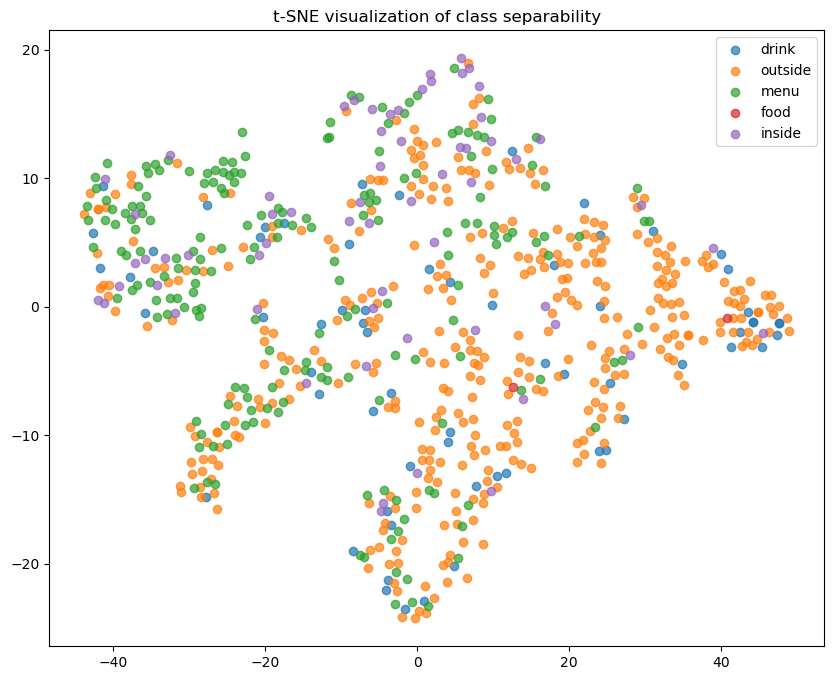

In [29]:
# Reshape the images to 2D (flatten each image)
X_train_flat = X_train.reshape(X_train.shape[0], -1)  # Flatten the images

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train_flat)  # Apply scaling to the flattened data

# PCA for dimensionality reduction (to 2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualize with t-SNE for better class separation in 2D
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

# Plotting the 2D t-SNE representation
plt.figure(figsize=(10, 8))
for label in np.unique(y_train):
    plt.scatter(X_tsne[y_train == label, 0], X_tsne[y_train == label, 1], label=class_labels[label], alpha=0.7)
plt.title('t-SNE visualization of class separability')
plt.legend()
plt.show()


In [44]:
# Reference
# https://chatgpt.com/share/679d25b9-1b90-8010-ab1d-12e42fde17a5
# APA - Model evaluation with Yelp Dataset